# Score-SDE for CIFAR-10 Grayscale Images

This notebook trains a Score-SDE (NCSN++) model on CIFAR-10 cat images converted to grayscale,
aligned with `score_sde_pytorch-main` defaults.

In [1]:
import os
import numpy as np
import torch
import pytorch_lightning as pl
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.utils import make_grid, save_image

from diffusion_lightning import (
    DiffusionModel,
    CIFAR10DataModule,
    CIFAR10_CLASSES,
    DEFAULT_SCORE_SDE_CONFIG,
    load_score_sde_config,
    apply_config_overrides,
    grab,
)

# Create directories
for folder in ['data', 'figures', 'models']:
    os.makedirs(folder, exist_ok=True)

# Check GPU
if torch.cuda.is_available():
    print(f"Available GPUs: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    print("No GPU available")

# Print available classes
print("\nCIFAR-10 Classes:")
for idx, name in CIFAR10_CLASSES.items():
    print(f"  {idx}: {name}")

W0117 10:03:47.039000 365630 site-packages/torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0117 10:03:47.039000 365630 site-packages/torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.
W0117 10:03:47.219000 365630 site-packages/torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W0117 10:03:47.219000 365630 site-packages/torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.


Available GPUs: 6
  GPU 0: NVIDIA GeForce RTX 4090
  GPU 1: NVIDIA GeForce RTX 4090
  GPU 2: NVIDIA GeForce RTX 5090
  GPU 3: NVIDIA GeForce RTX 5090
  GPU 4: NVIDIA GeForce RTX 2080 Ti
  GPU 5: NVIDIA GeForce RTX 2080 Ti

CIFAR-10 Classes:
  0: airplane
  1: automobile
  2: bird
  3: cat
  4: deer
  5: dog
  6: frog
  7: horse
  8: ship
  9: truck


## 1. Hyperparameters

In [2]:
# Score-SDE config (aligned with score_sde_pytorch-main)
config_name = DEFAULT_SCORE_SDE_CONFIG

# Data/model parameters
image_size = 32      # CIFAR-10 image size
num_channels = 1     # grayscale

# Training parameters
n_epochs = 100
batch_size = 1000
num_workers = 4

# Sampling parameters
num_samples = 64
sample_batch_size = 64
sampling_eps = None  # use default from SDE (VE uses 1e-5)

# GPU selection (change if needed)
gpu_id = 3
use_gpu = torch.cuda.is_available() and gpu_id is not None

# Class filter: train on specific class(es)
# Options:
#   - None: use all classes
#   - 'cat': only cat images
#   - 'dog': only dog images  
#   - ['cat', 'dog']: cat and dog images
#   - 3: class index for cat
class_filter = 'cat'  # Change this to train on different class(es)

# Config overrides for grayscale + batch size
config_overrides = {
    "data.num_channels": num_channels,
    "data.image_size": image_size,
    "training.batch_size": batch_size,
    # Smaller U-Net for grayscale cat subset
    "model.nf": 32,
    "model.ch_mult": (1, 2, 4, 8),
    # Sampling: Euler-Maruyama (EM)
    "sampling.method": "em",
}

config = load_score_sde_config(config_name)
apply_config_overrides(config, config_overrides)

# Get class name string for labels
if class_filter is not None:
    if isinstance(class_filter, list):
        class_name = '_'.join(str(c) for c in class_filter)
    else:
        class_name = str(class_filter)
else:
    class_name = 'all'
print(f"Training on class: {class_name}")

Training on class: cat


## 2. Load Data

In [3]:
# Initialize data module with class filter
data_module = CIFAR10DataModule(
    config=config,
    data_dir='./data/cifar10',
    batch_size=batch_size,
    num_workers=num_workers,
    class_filter=class_filter,
    grayscale=True,
)

# Download and setup
data_module.prepare_data()
data_module.setup()

train_loader = data_module.train_dataloader()

print(f"\nTraining samples: {len(data_module.train_data)}")

Filtered classes: ['cat'] (indices: [3])
Train images: 5000

Training samples: 5000


In [4]:
# Save training data for correlation analysis
# Format: (Lx, Ly, N) compatible with Julia correlation code
print("Saving training data for correlation analysis...")
train_loader = DataLoader(
    data_module.train_data,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers,
)
train_batches = []
for imgs, _ in train_loader:
    train_batches.append(imgs)
train_images_all = torch.cat(train_batches, dim=0)  # (N, 1, 32, 32)
train_images_np = train_images_all.numpy()  # Already in [0, 1] range
# Reshape from (N, 1, Lx, Ly) to (Lx, Ly, N)
train_cfgs = train_images_np[:, 0, :, :].transpose(1, 2, 0)  # (32, 32, N)
train_data_path = f'data/cifar10_{class_name}_train_{image_size}x{image_size}.npy'
np.save(train_data_path, train_cfgs)
print(f"Training data saved to: {train_data_path}")
print(f"  Shape: {train_cfgs.shape}")
print(f"  Range: [{train_cfgs.min():.3f}, {train_cfgs.max():.3f}]")

Saving training data for correlation analysis...
Training data saved to: data/cifar10_cat_train_32x32.npy
  Shape: (32, 32, 5000)
  Range: [0.000, 1.000]


## 3. Visualize Training Data

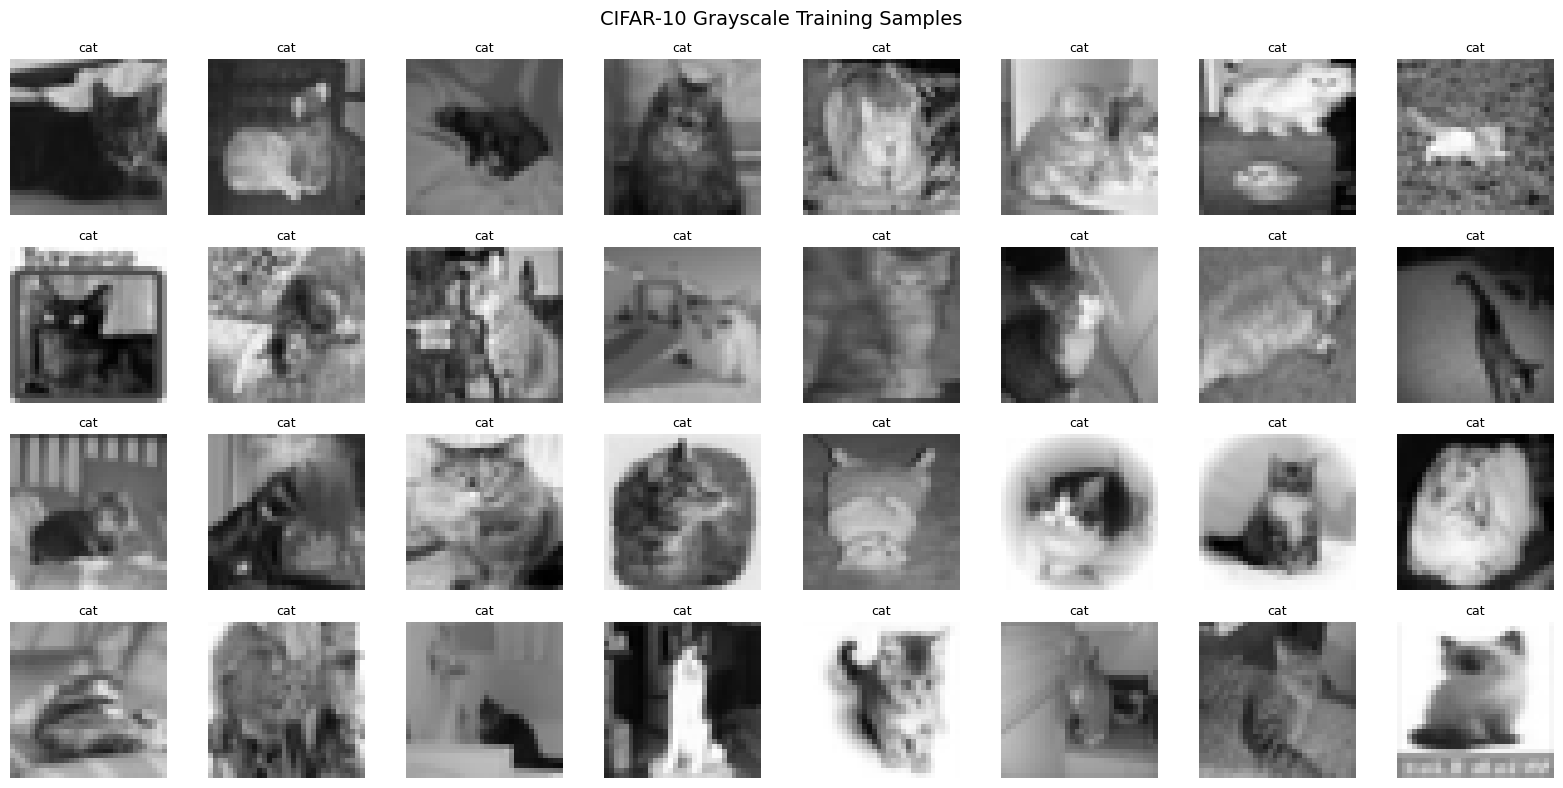

In [5]:
# CIFAR-10 class names
classes = CIFAR10_CLASSES

# Get a batch of training data
batch = next(iter(train_loader))
images, labels = batch

# Data is already in [0, 1] range (no renorm needed)
images_vis = images.numpy()

# Plot samples
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_vis[i, 0], cmap='gray', vmin=0, vmax=1)
    ax.set_title(classes[labels[i].item()], fontsize=9)
    ax.axis('off')
plt.suptitle('CIFAR-10 Grayscale Training Samples', fontsize=14)
plt.tight_layout()
plt.savefig('figures/cifar10_gray_training_samples.png', dpi=150)
plt.show()

## 4. Initialize Model

In [6]:
# Create model (Score-SDE)
model = DiffusionModel(
    config=config,
    use_ema=True,
)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 23,947,393
Trainable parameters: 23,947,361


## 5. Setup Training

In [ ]:
# Callbacks
sample_every_n_epochs = 200
sample_dir = f"runs/score_sde_cifar10/{class_name}/samples"
os.makedirs(sample_dir, exist_ok=True)

class SampleCallback(pl.Callback):
    def __init__(self, num_samples: int, sample_batch_size: int, sample_dir: str, every_n_epochs: int = 10):
        self.num_samples = 64
        self.sample_batch_size = 64
        self.sample_dir = sample_dir
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1
        if epoch % self.every_n_epochs != 0:
            return
        pl_module.eval()
        with torch.no_grad():
            samples = pl_module.sample(
                num_samples=self.num_samples,
                sample_batch_size=self.sample_batch_size,
                eps=1e-5,  # Use explicit eps value
            )
        # Debug: print sample statistics before clamping
        print(f"[Epoch {epoch}] Raw samples - min: {samples.min().item():.4f}, max: {samples.max().item():.4f}, mean: {samples.mean().item():.4f}")
        samples = samples.detach().cpu().clamp(0, 1)
        images_vis = samples.numpy()
        fig, axes = plt.subplots(4, 8, figsize=(16, 8))
        for i, ax in enumerate(axes.flat):
            ax.imshow(images_vis[i, 0], cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
        plt.suptitle(f'Generated Samples - Epoch {epoch}', fontsize=14)
        plt.tight_layout()
        fig_path = os.path.join(self.sample_dir, f"samples_epoch{epoch:04d}.png")
        fig.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        pl_module.train()

sample_callback = SampleCallback(
    num_samples=64,
    sample_batch_size=64,
    sample_dir=sample_dir,
    every_n_epochs=sample_every_n_epochs,
)

checkpoint_dir = 'models/score_sde_cifar10'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath=checkpoint_dir,
    filename=f'score_sde_cifar10_gray_{class_name}-epoch{{epoch:04d}}',
    save_top_k=-1,
    every_n_epochs=sample_every_n_epochs
)

# Trainer
trainer = pl.Trainer(
    max_epochs=10000,
    accelerator='gpu',
    devices=[3],
    callbacks=[sample_callback,checkpoint_callback],
    logger=False,
    enable_progress_bar=True,
    log_every_n_steps=50,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## 6. Train Model

In [ ]:
# Train!
trainer.fit(model, train_dataloaders=train_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5]

  | Name        | Type   | Params | Mode
----------------------------------------------
0 | score_model | NCSNpp | 23.9 M | eval
----------------------------------------------
23.9 M    Trainable params
32        Non-trainable params
23.9 M    Total params
95.790    Total estimated model params size (MB)
0         Modules in train mode
388       Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
print(f"Best model path: {checkpoint_callback.best_model_path}")
print(f"Best model score: {checkpoint_callback.best_model_score}")

## 7. Generate Samples

In [ ]:
# Load best model for sampling
best_model_path = checkpoint_callback.best_model_path
print(f"Loading checkpoint: {best_model_path}")
best_model = DiffusionModel.load_from_checkpoint(best_model_path, config=config)
if use_gpu:
    best_model = best_model.cuda(gpu_id)
best_model.eval()
print("Model loaded for sampling")

In [ ]:
# Number of samples to generate for correlation analysis
num_samples_gen = num_samples

# Generate samples
with torch.no_grad():
    samples = best_model.sample(
        num_samples=num_samples_gen,
        sample_batch_size=sample_batch_size,
        eps=sampling_eps,
    )

    # Convert to numpy
    samples_np = grab(samples)
    # No renorm or clip - keep raw output values

    print(f"Generated {samples_np.shape[0]} samples")
    print(f"Sample range: [{samples_np.min():.3f}, {samples_np.max():.3f}]")

In [ ]:
# Save generated samples for correlation analysis
# Format: (Lx, Ly, N) compatible with Julia correlation code
print("Saving generated samples for correlation analysis...")
# Reshape from (N, 1, Lx, Ly) to (Lx, Ly, N)
gen_cfgs = samples_np[:, 0, :, :].transpose(1, 2, 0)  # (32, 32, N)
gen_data_path = f'data/cifar10_{class_name}_dm_{image_size}x{image_size}.npy'
np.save(gen_data_path, gen_cfgs)
print(f"Generated samples saved to: {gen_data_path}")
print(f"  Shape: {gen_cfgs.shape}")
print(f"  Range: [{gen_cfgs.min():.3f}, {gen_cfgs.max():.3f}]")

## 8. Visualize Results

In [ ]:
# Plot all generated samples (raw output, no normalization)
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples_np[i, 0], cmap='gray')  # No vmin/vmax to see actual range
    ax.axis('off')
plt.suptitle('Generated CIFAR-10 Grayscale Images (Raw)', fontsize=16)
plt.tight_layout()
plt.savefig('figures/cifar10_generated_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Compare real vs generated
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

# Get real samples from training data (already in [0, 1] range)
real_batch = next(iter(train_loader))
real_images = real_batch[0][:8].numpy()  # No renorm needed

# Top row: real
for i in range(8):
    axes[0, i].imshow(real_images[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Real', fontsize=12)

# Bottom row: generated (raw output, may exceed [0,1])
for i in range(8):
    axes[1, i].imshow(samples_np[i, 0], cmap='gray')  # No vmin/vmax to see actual range
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('Generated', fontsize=12)

plt.suptitle('Real vs Generated CIFAR-10-Cat Grayscale', fontsize=14)
plt.tight_layout()
plt.savefig('figures/cifar10_real_vs_generated.png', dpi=150)
plt.show()

In [ ]:
# (Deprecated) Custom score_sde_wrapper workflow removed.
# Use the DiffusionModel + CIFAR10DataModule pipeline above.

In [ ]:
# (Deprecated) See training section above.

In [ ]:
# (Deprecated) See training section above.

In [ ]:
# (Deprecated) See sampling section above.

In [ ]:
# (Deprecated) See sampling/visualization section above.